# SVD troncata per il completamento di matrici utenti-film

## Perché la SVD per un sistema di raccomandazione

Un sistema di raccomandazione deve rispondere a una domanda molto concreta: dato che un utente non ha ancora votato (o comprato, o guardato) un certo prodotto, quale voto gli assegnerebbe? Un approccio possibile è basato sul **contenuto**: conoscere il genere, gli attori, la trama di ogni film, e cercare somiglianze tra prodotti. Il **collaborative filtering** prende una strada diversa e, su larga scala, sorprendentemente efficace: ignora completamente il contenuto e sfrutta solo la matrice dei voti. L'idea è che se due utenti hanno votato in modo simile sui film che hanno entrambi visto, è ragionevole aspettarsi che voteranno in modo simile anche sui film che solo uno dei due ha visto — è esattamente il meccanismo dietro il grafico dei fattori latenti dello Step 4: utenti vicini in quello spazio hanno gusti simili, senza che il modello sappia nulla di generi cinematografici.

Il caso di studio storico che ha reso popolare questa idea è il **Netflix Prize** (2006-2009): Netflix mise in palio un milione di dollari per chi avesse migliorato del 10% l'accuratezza (misurata in RMSE) del proprio sistema di raccomandazione interno, *Cinematch*, su un dataset reale di circa 100 milioni di voti. Le soluzioni vincenti (in particolare gli approcci ispirati al lavoro di Simon Funk, poi raffinati dal team BellKor's Pragmatic Chaos) si basavano su **fattorizzazioni a basso rango** della matrice utenti-film, concettualmente identiche alla SVD troncata usata in questo notebook: rappresentare ogni utente e ogni film con un piccolo vettore di "fattori latenti" — che nella pratica finiscono per correlare, senza essere programmati esplicitamente a farlo, con caratteristiche interpretabili come il genere del film o quanto è mainstream — e prevedere un voto mancante come prodotto scalare tra i due vettori.

Va anticipato un punto tecnico che distingue questo notebook didattico dagli approcci usati in produzione (ripreso per esteso nell'ultima sezione): i sistemi reali non calcolano la SVD esatta su una matrice riempita a mano, ma addestrano una fattorizzazione a basso rango ottimizzando l'errore soltanto sui voti effettivamente osservati. Qui si usa invece la SVD esatta — che richiede una matrice completa — applicata dopo un'imputazione preliminare con la media.

## Step 1 — Matrice utenti-film (toy dataset)

Il punto di partenza è una matrice $R$ di voti, righe = utenti, colonne = film: $R_{ij}$ è il voto (da 1 a 5) che l'utente $i$ ha dato al film $j$, quando quel voto esiste. Nella pratica nessun utente vede (né vota) tutti i film disponibili, quindi $R$ ha molte voci **mancanti**: qui le rappresentiamo con `np.nan`, e costruiamo separatamente una maschera booleana `mask_known` che distingue in ogni posizione un voto osservato da uno mancante — distinzione che servirà negli step successivi sia per il confronto con la baseline sia per valutare correttamente l'errore di ricostruzione (solo sulle voci note, mai su quelle che abbiamo noi stessi riempito).

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from src.svd_tools import svd_truncate, reconstruction_error

users = ["Anna", "Bruno", "Carla", "Davide", "Elena", "Fabio"]
films = ["La Nave Stellare", "Cronache del Deserto", "Amore a Roma", "Risate in Ufficio", "Il Detective"]

# Voti da 1 a 5, definiti a mano; np.nan = voto mancante.
R = np.array([
    [5.0, 4.0, np.nan, 2.0, np.nan],  # Anna
    [4.0, 5.0, 2.0, np.nan, 3.0],     # Bruno
    [np.nan, 2.0, 5.0, 4.0, 3.0],     # Carla
    [2.0, np.nan, 4.0, 5.0, np.nan],  # Davide
    [5.0, 4.0, 2.0, np.nan, 4.0],     # Elena
    [np.nan, 1.0, 4.0, 5.0, 2.0],     # Fabio
])
R

array([[ 5.,  4., nan,  2., nan],
       [ 4.,  5.,  2., nan,  3.],
       [nan,  2.,  5.,  4.,  3.],
       [ 2., nan,  4.,  5., nan],
       [ 5.,  4.,  2., nan,  4.],
       [nan,  1.,  4.,  5.,  2.]])

Costruiamo `mask_known` e visualizziamo `R` come heatmap: ogni cella mostra il voto numerico, e le voci mancanti risultano immediatamente visibili sia come buco nella heatmap (colore neutro, nessun valore annotato) sia come `False` nella maschera.

R =
[[ 5.  4. nan  2. nan]
 [ 4.  5.  2. nan  3.]
 [nan  2.  5.  4.  3.]
 [ 2. nan  4.  5. nan]
 [ 5.  4.  2. nan  4.]
 [nan  1.  4.  5.  2.]]

mask_known =
[[ True  True False  True False]
 [ True  True  True False  True]
 [False  True  True  True  True]
 [ True False  True  True False]
 [ True  True  True False  True]
 [False  True  True  True  True]]


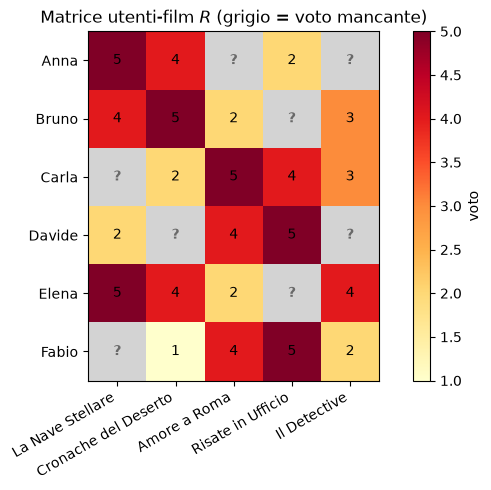

In [2]:
mask_known = ~np.isnan(R)

print("R =")
print(R)
print("\nmask_known =")
print(mask_known)

fig, ax = plt.subplots(figsize=(7, 5))
R_masked = np.ma.masked_invalid(R)
cmap = plt.get_cmap("YlOrRd").copy()
cmap.set_bad(color="lightgray")
im = ax.imshow(R_masked, cmap=cmap, vmin=1, vmax=5)

ax.set_xticks(range(len(films)))
ax.set_xticklabels(films, rotation=30, ha="right")
ax.set_yticks(range(len(users)))
ax.set_yticklabels(users)

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if mask_known[i, j]:
            ax.text(j, i, f"{R[i, j]:.0f}", ha="center", va="center", color="black")
        else:
            ax.text(j, i, "?", ha="center", va="center", color="dimgray", fontweight="bold")

fig.colorbar(im, ax=ax, label="voto")
ax.set_title("Matrice utenti-film $R$ (grigio = voto mancante)")
plt.tight_layout()
plt.show()

## Step 2 — Baseline: imputazione con la media

Prima di ricorrere alla SVD conviene fissare un riferimento semplice, senza alcun apprendimento: per ogni voto mancante, si usa la media dei voti osservati per quel film. È una baseline "ingenua" — non tiene conto delle preferenze specifiche dell'utente, solo della popolarità media del film — ma è proprio questo che la rende utile: negli step successivi si potrà verificare se la SVD fa qualcosa di più intelligente di questa non-soluzione, o se si limita a riprodurla.

In [3]:
film_means = np.nanmean(R, axis=0)
R_filled = np.where(mask_known, R, film_means)

print("media dei voti osservati per film:")
print(np.round(film_means, 2))
print("\nR_filled =")
print(np.round(R_filled, 2))

media dei voti osservati per film:
[4.  3.2 3.4 4.  3. ]

R_filled =
[[5.  4.  3.4 2.  3. ]
 [4.  5.  2.  4.  3. ]
 [4.  2.  5.  4.  3. ]
 [2.  3.2 4.  5.  3. ]
 [5.  4.  2.  4.  4. ]
 [4.  1.  4.  5.  2. ]]


## Step 3 — SVD troncata e ricostruzione

Applichiamo a `R_filled` la fattorizzazione ai valori singolari: $A = U\Sigma V^T$, con $U$ e $V$ ortogonali e $\Sigma$ diagonale con i valori singolari $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$. Troncando la somma ai primi $k$ termini,

$$A_k = \sum_{i=1}^{k} \sigma_i\, u_i v_i^T = U_{:,:k}\,\Sigma_{:k,:k}\,V^T_{:k,:},$$

si ottiene — per il teorema di Eckart-Young — la migliore approssimazione di rango $k$ di $A$ in norma di Frobenius (e in norma-2): nessun'altra matrice di rango $\le k$ è più vicina ad $A$. È esattamente la stessa idea usata per comprimere un'immagine tenendo solo i $k$ fattori latenti più significativi; qui il dominio cambia — non un'immagine ma una matrice di voti — ma la matematica è identica.

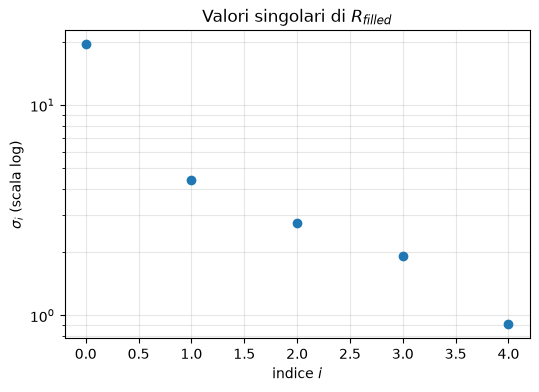

valori singolari: [19.432  4.385  2.743  1.907  0.905]


In [4]:
U, s, Vt = np.linalg.svd(R_filled, full_matrices=False)

plt.figure(figsize=(6, 4))
plt.semilogy(s, 'o')
plt.xlabel("indice $i$")
plt.ylabel("$\\sigma_i$ (scala log)")
plt.title("Valori singolari di $R_{filled}$")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("valori singolari:", np.round(s, 3))

Nel grafico si vede un salto di quasi un ordine di grandezza tra $\sigma_1$ e $\sigma_2$ — il primo valore singolare cattura soprattutto il livello medio dei voti, comune a tutta la matrice — seguito da un decadimento molto più graduale per $\sigma_2,\sigma_3,\sigma_4,\sigma_5$. Scegliamo quindi $k=2$: la prima componente per il livello medio, la seconda per il principale asse di gusto che distingue gli utenti (già visibile nella heatmap dello Step 1: fan di fantascienza/azione contro fan di romantico/commedia).

In [5]:
k = 2
R_k = svd_truncate(R_filled, k)

err = reconstruction_error(R_filled, R_k, mask_known)

print(f"R_{k} (approssimazione di rango {k}) =")
print(np.round(R_k, 2))
print(f"\nerrore di ricostruzione sulle sole voci note = {err:.4f}")

R_2 (approssimazione di rango 2) =
[[4.29 4.15 2.42 3.27 3.21]
 [4.54 4.52 2.33 3.27 3.39]
 [3.69 2.18 4.44 4.79 2.8 ]
 [3.57 2.29 3.99 4.38 2.71]
 [4.73 4.56 2.67 3.61 3.53]
 [3.17 1.46 4.51 4.7  2.42]]

errore di ricostruzione sulle sole voci note = 2.9307


## Step 4 — Predizione dei voti mancanti e fattori latenti

Nelle posizioni dove `mask_known` è `False`, il valore corrispondente in `R_k` non è più un dato osservato ma una **predizione**: è ciò che il modello a rango basso "inventa" per un voto mai dato, sulla base dei pattern imparati dal resto della matrice (le correlazioni tra utenti e tra film catturate dai due fattori latenti scelti). Confrontiamo queste predizioni con la baseline `R_filled` nelle stesse posizioni, per vedere se la SVD si limita a riprodurre la media del film o fa qualcosa di più mirato sull'utente specifico.

In [6]:
missing_idx = np.argwhere(~mask_known)

print(f"{'utente':<8}{'film':<24}{'baseline (media)':<18}{'predizione SVD':<16}{'differenza':<10}")
for i, j in missing_idx:
    baseline = R_filled[i, j]
    svd_pred = R_k[i, j]
    print(f"{users[i]:<8}{films[j]:<24}{baseline:<18.2f}{svd_pred:<16.2f}{svd_pred - baseline:<+10.2f}")

utente  film                    baseline (media)  predizione SVD  differenza
Anna    Amore a Roma            3.40              2.42            -0.98     
Anna    Il Detective            3.00              3.21            +0.21     
Bruno   Risate in Ufficio       4.00              3.27            -0.73     
Carla   La Nave Stellare        4.00              3.69            -0.31     
Davide  Cronache del Deserto    3.20              2.29            -0.91     
Davide  Il Detective            3.00              2.71            -0.29     
Elena   Risate in Ufficio       4.00              3.61            -0.39     
Fabio   La Nave Stellare        4.00              3.17            -0.83     


Le differenze in tabella non sono casuali: riflettono la struttura a due fattori appena estratta. Per vederla direttamente, rappresentiamo ogni utente come un punto nel piano $(u_{i,1}, u_{i,2})$, cioè le sue coordinate nelle prime due colonne di $U$ — lo spazio a bassa dimensione su cui la troncatura a rango $k=2$ ha proiettato l'intera matrice.

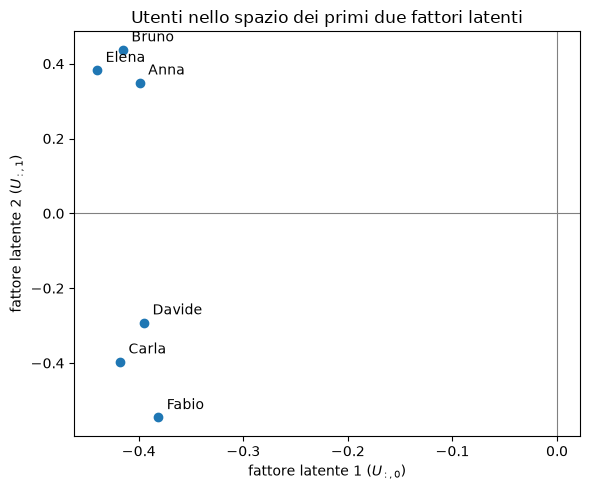

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(U[:, 0], U[:, 1], color="tab:blue")
for i, name in enumerate(users):
    ax.annotate(name, (U[i, 0], U[i, 1]), textcoords="offset points", xytext=(6, 6))

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("fattore latente 1 ($U_{:,0}$)")
ax.set_ylabel("fattore latente 2 ($U_{:,1}$)")
ax.set_title("Utenti nello spazio dei primi due fattori latenti")
plt.tight_layout()
plt.show()

Il grafico mostra due gruppi ben separati lungo il secondo fattore latente: Anna, Bruno ed Elena da un lato, Carla, Davide e Fabio dall'altro — esattamente i due profili di gusto (fantascienza/azione contro romantico/commedia) già visibili "a occhio" nella heatmap dello Step 1, ma qui emersi automaticamente dalla sola struttura numerica dei voti, senza che il modello sapesse nulla di generi cinematografici. Utenti vicini in questo spazio hanno votato in modo simile sui film che entrambi hanno visto, e il modello tende quindi a predire per loro voti simili anche sui film che uno dei due non ha ancora votato: è esattamente il meccanismo alla base delle predizioni della tabella qui sopra, ed è l'idea di fondo del *collaborative filtering* — filtrare/predire le preferenze di un utente sulla base delle preferenze di utenti "vicini", senza bisogno di conoscere il contenuto dei film (approfondito nello Step 5).

Concettualmente, è la **stessa identica matematica** che sta dietro alla compressione di immagini via SVD: la migliore approssimazione di rango $k$ garantita dal teorema di Eckart-Young (richiamato allo Step 3). Cambia solo lo scopo con cui la si legge. Per un'immagine, la si usa per **comprimere**: ridurre il numero di parametri necessari a rappresentare i dati, mantenendo solo le direzioni (fattori) che contengono la maggior parte dell'informazione, e accettando un piccolo errore di ricostruzione ovunque. Per una matrice di voti, la si usa per **completare**: le posizioni mancanti non hanno mai un valore "vero" con cui calcolare un errore, quindi la stessa proiezione a basso rango non è più letta come un'approssimazione lossy di dati noti, ma come un'estrapolazione — il valore più plausibile per quella cella, dato tutto ciò che il modello ha imparato sulla struttura a bassa dimensione del resto della matrice.

## Limiti del modello e cosa si farebbe in produzione

Il procedimento seguito in questo notebook — imputare i buchi con la media (Step 2) e poi calcolare la SVD esatta della matrice piena risultante (Step 3-4) — è una scelta didattica, pensata per usare la stessa tecnica di troncamento SVD illustrata nello Step 3, non l'approccio che si userebbe in un sistema reale. Vanno tenuti presenti due limiti, entrambi conseguenza diretta di questa scelta:

1. **I valori inventati dalla media pesano quanto quelli osservati.** La SVD dello Step 3 minimizza l'errore di ricostruzione su *tutta* la matrice `R_filled`, comprese le celle che noi stessi abbiamo riempito con un valore arbitrario (la media del film). Il modello, senza saperlo, sta quindi cercando di "spiegare bene" anche dati che non sono reali — un rischio tanto più serio quanto più la matrice è sparsa (poche voci osservate, molte imputate), che è esattamente il caso di ogni sistema di raccomandazione reale, dove la stragrande maggioranza delle coppie utente-prodotto non ha mai un voto.
2. **La soluzione usata in produzione ottimizza solo sui dati osservati.** Gli algoritmi realmente impiegati — discesa del gradiente stocastica sui soli voti noti, oppure ALS (*Alternating Least Squares*, che alterna la stima dei fattori utente e dei fattori film tenendo l'altro fisso) — non richiedono mai di riempire preventivamente i buchi: la funzione di costo minimizzata è definita fin dall'inizio solo sulle posizioni di `mask_known`, e le celle mancanti non compaiono mai nel calcolo dell'errore, né durante l'addestramento né dopo. La predizione finale per una cella mancante resta comunque il prodotto tra il vettore latente dell'utente e quello del film — la stessa idea geometrica vista nello Step 4 — ma senza il passaggio intermedio, concettualmente scorretto, di trattare un valore inventato come se fosse un dato osservato.

Per una matrice giocattolo di questa dimensione la differenza tra i due approcci è quantitativamente piccola (lo conferma l'errore di ricostruzione dello Step 3), ma diventa rilevante — e la scelta dell'algoritmo importante — non appena si passa a matrici reali con milioni di utenti e prodotti e una frazione di voti osservati molto piccola.